<a href="https://colab.research.google.com/github/Ra1nbb0w/4Dmamba/blob/main/4Dmamba.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ==============================================================================
# Cell 1: Environment Setup, High-Speed Local Caching, and Mamba CUDA Verification
# Description:
# 1. Mount Google Drive and cache the dataset to the local Colab NVMe SSD.
# 2. Install causal-conv1d and mamba-ssm precompiled wheels directly from release.
# 3. Verify GPU access and execute a dummy forward pass through the Mamba CUDA kernel.
# ==============================================================================

import glob
import os
import shutil
import torch

# 1. Clean residual mounts and remount Google Drive
!fusermount -uz /content/drive 2>/dev/null || true
!rm -rf /content/drive
from google.colab import drive
drive.mount('/content/drive')

# 2. Define source (Google Drive) and destination (local SSD) paths
DRIVE_TRAIN_DIR = '/content/drive/MyDrive/ACDC/ACDC/database/training'
DRIVE_TEST_DIR = '/content/drive/MyDrive/ACDC/ACDC/database/testing'

LOCAL_DATASET_DIR = '/content/dataset'
LOCAL_TRAIN_DIR = '/content/dataset/training'
LOCAL_TEST_DIR = '/content/dataset/testing'

# Clean local cache to prevent data corruption
if os.path.exists(LOCAL_DATASET_DIR):
    print("Cleaning existing local dataset directory...")
    shutil.rmtree(LOCAL_DATASET_DIR)
os.makedirs(LOCAL_DATASET_DIR, exist_ok=True)

# 3. Copy dataset directly to local NVMe SSD to eliminate I/O bottlenecks[cite: 1, 3]
print("Copying ACDC dataset from Google Drive to local SSD...")
!cp -r "$DRIVE_TRAIN_DIR" /content/dataset/
if os.path.exists(DRIVE_TEST_DIR):
    !cp -r "$DRIVE_TEST_DIR" /content/dataset/
print("Dataset successfully cached to local SSD.")

# 4. Verify patient sample counts[cite: 1, 3]
train_patients = sorted(glob.glob(os.path.join(LOCAL_TRAIN_DIR, 'patient*')))
print(f"Local training cohort ready: {len(train_patients)} patients (Expected: 100)")
if os.path.exists(LOCAL_TEST_DIR):
    test_patients = sorted(glob.glob(os.path.join(LOCAL_TEST_DIR, 'patient*')))
    print(f"Local testing cohort ready: {len(test_patients)} patients (Expected: 50)")

# 5. Install medical imaging libraries and official Mamba wheels
!pip install -q nibabel monai einops scikit-learn pandas tqdm
!pip install --no-build-isolation causal-conv1d>=1.2.0
!pip install --no-build-isolation mamba-ssm

# 6. Verify hardware setup and Mamba selective scan forward propagation]
import mamba_ssm
from mamba_ssm import Mamba

print(f"CUDA Available: {torch.cuda.is_available()}")
print(f"Current GPU: {torch.cuda.get_device_name(0)}")

# Run a synthetic sequence tensor: (Batch=2, Time=20, Embed_Dim=256)
dummy_x = torch.randn(2, 20, 256).cuda()
dummy_mamba = Mamba(d_model=256, d_state=16, d_conv=4, expand=2).cuda()
dummy_out = dummy_mamba(dummy_x)
print(f"Mamba CUDA kernel verified successfully! Output shape: {dummy_out.shape}")

Mounted at /content/drive
Copying ACDC dataset from Google Drive to local SSD...
Dataset successfully cached to local SSD.
Local training cohort ready: 100 patients (Expected: 100)
Local testing cohort ready: 50 patients (Expected: 50)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 74.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 216.4/216.4 kB 17.5 MB/s eta 0:00:00
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.5/43.5 MB 58.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 96.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 729.6/729.6 kB 56.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 101.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.7/88.7 MB 27.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 83.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 29.3/29.3 MB 90.9 MB/s eta 0:00:00
   ━━━━━━

In [2]:
# ==============================================================================
# Cell 2: Global Hyperparameters, 4D Preprocessing Pipeline, and Bidirectional Mamba
# Description:
# 1. Fix global random seeds and establish a standardized 5-class diagnosis mapping.
# 2. TransferACDC4DDataset: Reads 4D NIfTI volumes, uniformly resamples T=20 cardiac frames,
#    performs 3D center cropping/padding across (Z, H, W), and applies Z-score normalization.
# 3. VideoMambaBlock: Implements forward and backward bidirectional selective state-space
#    scans to model cyclic contraction and relaxation dynamics across the cardiac cycle.
# ==============================================================================

import random
import numpy as np
import nibabel as nib
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score
from einops import rearrange
from mamba_ssm import Mamba

# ----------------- Global Seed Initialization -----------------
SEED = 42
def seed_everything(seed=42):
    """Fix random seeds across all libraries to promote reproducible experiments."""
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(SEED)

# ----------------- Hyperparameters & Paths -----------------
DATASET_DIR = '/content/dataset/training'
SAVE_DIR = '/content/drive/MyDrive/ACDC_VideoMamba_Transfer'
os.makedirs(SAVE_DIR, exist_ok=True)

# Target 4D spatio-temporal specification: 20 temporal frames, 10 slices, 128x128 in-plane resolution
TARGET_T, TARGET_Z, TARGET_H, TARGET_W = 20, 10, 128, 128
NUM_CLASSES = 5      # 5 cardiac pathologies: NOR, MINF, DCM, HCM, RV
EPOCHS = 60          # Training epochs
BATCH_SIZE = 4       # Mini-batch size
EMBED_DIM = 192      # Spatial latent feature & Mamba state dimension
DEPTH = 6            # Number of stacked Mamba layers
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Diagnosis string-to-integer mapping
DIAGNOSIS_MAP = {'NOR': 0, 'MINF': 1, 'DCM': 2, 'HCM': 3, 'RV': 4, 'ARV': 4}

# ----------------- 4D Dataset Definition -----------------
class TransferACDC4DDataset(Dataset):
    """
    ACDC 4D Dynamic Cine-MRI Dataset Loader:
    Extracts 4D NIfTI sequences, aligns temporal dimension to T=20, applies 3D
    spatial center cropping/padding, and computes per-frame Z-score intensity normalization.
    """
    def __init__(self, patient_folders, is_train=True):
        self.patient_folders = patient_folders
        self.is_train = is_train

    def __len__(self):
        return len(self.patient_folders)

    def _pad_or_crop_3d(self, vol):
        """Performs 3D spatial center cropping or zero-padding along (Z, H, W)."""
        z, h, w = vol.shape
        # Z-axis (slice count) alignment
        if z < TARGET_Z:
            vol = np.pad(vol, ((0, TARGET_Z - z), (0, 0), (0, 0)), mode='constant')
        elif z > TARGET_Z:
            st_z = (z - TARGET_Z) // 2
            vol = vol[st_z:st_z + TARGET_Z, :, :]
        # H-axis (height) alignment
        if h < TARGET_H:
            vol = np.pad(vol, ((0, 0), ((TARGET_H - h)//2, (TARGET_H - h) - (TARGET_H - h)//2), (0, 0)), mode='constant')
        elif h > TARGET_H:
            vol = vol[:, (h - TARGET_H)//2:(h - TARGET_H)//2 + TARGET_H, :]
        # W-axis (width) alignment
        if w < TARGET_W:
            vol = np.pad(vol, ((0, 0), (0, 0), ((TARGET_W - w)//2, (TARGET_W - w) - (TARGET_W - w)//2)), mode='constant')
        elif w > TARGET_W:
            vol = vol[:, :, (w - TARGET_W)//2:(w - TARGET_W)//2 + TARGET_W]
        return vol

    def __getitem__(self, idx):
        p_path = self.patient_folders[idx]
        p_id = os.path.basename(p_path)

        # 1. Parse Info.cfg for diagnosis label
        with open(os.path.join(p_path, 'Info.cfg'), 'r', encoding='utf-8') as f:
            for line in f:
                if line.startswith('Group:'):
                    group = line.split(':')[1].strip().upper()
                    break
        label = DIAGNOSIS_MAP[group]

        # 2. Read 4D NIfTI and transpose axes to (T, Z, H, W)
        cine_file = os.path.join(p_path, f"{p_id}_4d.nii.gz")
        data_4d = np.transpose(nib.load(cine_file).get_fdata(dtype=np.float32), (3, 2, 0, 1))

        # 3. Uniformly resample TARGET_T=20 frames across the cardiac cycle
        indices = np.linspace(0, data_4d.shape[0] - 1, TARGET_T).astype(int)
        data_4d = data_4d[indices]

        # 4. Perform 3D cropping/padding and Z-score standardization frame by frame
        processed = []
        for t in range(TARGET_T):
            frame = self._pad_or_crop_3d(data_4d[t])
            mean, std = np.mean(frame), np.std(frame) + 1e-8
            processed.append((frame - mean) / std)

        # Expand channel dimension: (C=1, T=20, Z=10, H=128, W=128)
        tensor_4d = torch.from_numpy(np.stack(processed, axis=0)).float().unsqueeze(0)

        # 5. Spatial data augmentation for training
        if self.is_train:
            if random.random() > 0.5:
                tensor_4d = torch.flip(tensor_4d, dims=[3])  # Horizontal flip along H
            if random.random() > 0.5:
                tensor_4d = torch.flip(tensor_4d, dims=[4])  # Vertical flip along W

        return tensor_4d, torch.tensor(label, dtype=torch.long)

# ----------------- Bidirectional Mamba Block -----------------
class VideoMambaBlock(nn.Module):
    """
    Bidirectional Mamba Operator:
    Uses parallel forward and backward selective state-space scans to capture
    bidirectional strain dynamics (diastole-to-systole and systole-to-diastole).
    """
    def __init__(self, embed_dim=192):
        super().__init__()
        self.fwd_mamba = Mamba(d_model=embed_dim, d_state=16, d_conv=4, expand=2)
        self.bwd_mamba = Mamba(d_model=embed_dim, d_state=16, d_conv=4, expand=2)
        self.norm = nn.LayerNorm(embed_dim)

    def forward(self, x):
        out_fwd = self.fwd_mamba(x)
        out_bwd = torch.flip(self.bwd_mamba(torch.flip(x, dims=[1])), dims=[1])
        return self.norm(x + out_fwd + out_bwd)

# ----------------- Shared Training & Evaluation Loops -----------------
def train_epoch(model, loader, criterion, optimizer, scaler):
    """Single training epoch using automatic mixed precision (AMP)."""
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for data, labels in loader:
        data, labels = data.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        with torch.amp.autocast('cuda', dtype=torch.bfloat16):
            outputs = model(data)
            loss = criterion(outputs, labels)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item() * data.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += data.size(0)
    return total_loss / total, correct / total

@torch.no_grad()
def eval_epoch(model, loader, criterion):
    """Single validation epoch evaluating Loss, Accuracy, and Macro-F1 score."""
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []
    for data, labels in loader:
        data, labels = data.to(DEVICE), labels.to(DEVICE)
        with torch.amp.autocast('cuda', dtype=torch.bfloat16):
            outputs = model(data)
            loss = criterion(outputs, labels)

        total_loss += loss.item() * data.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += data.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    f1 = f1_score(all_labels, all_preds, average='macro')
    return total_loss / total, correct / total, f1

# Initialize stratified cross-validation split
patient_list = sorted(glob.glob(os.path.join(DATASET_DIR, "patient*")))
labels = [DIAGNOSIS_MAP[open(os.path.join(p, 'Info.cfg')).read().split('Group:')[1].split()[0].upper()] for p in patient_list]
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)
print(f"Shared components initialized. Loaded {len(patient_list)} patients across 3 stratified folds.")

Shared components initialized. Loaded 100 patients across 3 stratified folds.


In [3]:
# ==============================================================================
# Cell 3: Exp 1 - Training From Scratch + Single Mean Pooling (Mean-Only)
# Ablation Configuration:
# 1. Architecture: Randomly initialized 3D-CNN and Mamba; classification head relies
#    solely on temporal mean pooling across T=20 frames (192-d).
# 2. Optimization: Unified end-to-end learning rate of lr=1e-4 across all layers.
# ==============================================================================

class VideoMambaExp1(nn.Module):
    def __init__(self, embed_dim=192, depth=6, num_classes=5):
        super().__init__()
        self.embed_dim = embed_dim
        # 3D spatial encoder: downsamples (1, 10, 128, 128) to an embed_dim feature vector
        self.spatial_encoder = nn.Sequential(
            nn.Conv3d(1, 32, kernel_size=3, stride=(1, 2, 2), padding=1),
            nn.BatchNorm3d(32),
            nn.SiLU(),
            nn.Conv3d(32, 64, kernel_size=3, stride=(1, 2, 2), padding=1),
            nn.BatchNorm3d(64),
            nn.SiLU(),
            nn.Conv3d(64, embed_dim, kernel_size=3, stride=(2, 2, 2), padding=1),
            nn.BatchNorm3d(embed_dim),
            nn.SiLU(),
            nn.AdaptiveAvgPool3d((1, 1, 1))
        )
        self.blocks = nn.ModuleList([VideoMambaBlock(embed_dim=embed_dim) for _ in range(depth)])
        self.norm = nn.LayerNorm(embed_dim)
        # Single mean pooling head: input dimension is embed_dim (192)
        self.head = nn.Sequential(
            nn.Linear(embed_dim, 64),
            nn.LayerNorm(64),
            nn.SiLU(),
            nn.Dropout(0.4),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        B, C, T, Z, H, W = x.shape
        x_flat = rearrange(x, 'b c t z h w -> (b t) c z h w')
        tokens = self.spatial_encoder(x_flat).flatten(1)
        seq = rearrange(tokens, '(b t) d -> b t d', b=B, t=T)

        for blk in self.blocks:
            seq = blk(seq)
        seq = self.norm(seq)

        # Single mean pooling along the temporal axis
        feat = torch.mean(seq, dim=1)
        return self.head(feat)

print("Starting Exp 1: Training From Scratch + Single Mean Pooling (Mean-Only)...")
fold_accs_exp1 = []

for fold, (train_idx, val_idx) in enumerate(skf.split(patient_list, labels)):
    print(f"\n==================== Exp 1 - Fold {fold + 1} / 3 ====================")
    train_loader = DataLoader(TransferACDC4DDataset([patient_list[i] for i in train_idx], is_train=True), batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
    val_loader = DataLoader(TransferACDC4DDataset([patient_list[i] for i in val_idx], is_train=False), batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

    model = VideoMambaExp1(embed_dim=EMBED_DIM, depth=DEPTH, num_classes=NUM_CLASSES).to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-2)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.08)
    scaler = torch.amp.GradScaler('cuda')

    best_acc, best_f1 = 0.0, 0.0
    for epoch in range(1, EPOCHS + 1):
        tr_loss, tr_acc = train_epoch(model, train_loader, criterion, optimizer, scaler)
        va_loss, va_acc, va_f1 = eval_epoch(model, val_loader, criterion)
        scheduler.step()
        if va_acc > best_acc:
            best_acc = va_acc
            best_f1 = va_f1
            torch.save(model.state_dict(), os.path.join(SAVE_DIR, f"videomamba_exp1_best_fold{fold+1}.pth"))
        if epoch % 10 == 0 or epoch == EPOCHS:
            print(f"Epoch [{epoch:02d}/{EPOCHS:02d}] | Train Loss: {tr_loss:.4f} Acc: {tr_acc:.3f} | Val Loss: {va_loss:.4f} Acc: {va_acc:.3f} F1: {va_f1:.3f}")

    print(f"Fold {fold + 1} Best Validation Accuracy: {best_acc * 100:.2f}%, Macro-F1: {best_f1:.3f}")
    fold_accs_exp1.append(best_acc)

print(f"\nExp 1 (Scratch + Mean) 3-Fold Mean Accuracy: {np.mean(fold_accs_exp1)*100:.2f}% ± {np.std(fold_accs_exp1)*100:.2f}%")

Starting Exp 1: Training From Scratch + Single Mean Pooling (Mean-Only)...

==================== Exp 1 - Fold 1 / 3 ====================
Epoch [10/60] | Train Loss: 1.2015 Acc: 0.591 | Val Loss: 1.5286 Acc: 0.441 F1: 0.428
Epoch [20/60] | Train Loss: 1.0189 Acc: 0.712 | Val Loss: 1.5914 Acc: 0.294 F1: 0.230
Epoch [30/60] | Train Loss: 0.7712 Acc: 0.864 | Val Loss: 1.6204 Acc: 0.265 F1: 0.241
Epoch [40/60] | Train Loss: 0.6143 Acc: 0.955 | Val Loss: 1.7143 Acc: 0.206 F1: 0.193
Epoch [50/60] | Train Loss: 0.5954 Acc: 0.939 | Val Loss: 1.7608 Acc: 0.324 F1: 0.304
Epoch [60/60] | Train Loss: 0.5226 Acc: 0.985 | Val Loss: 1.7530 Acc: 0.412 F1: 0.411
Fold 1 Best Validation Accuracy: 50.00%, Macro-F1: 0.451

==================== Exp 1 - Fold 2 / 3 ====================
Epoch [10/60] | Train Loss: 1.3608 Acc: 0.448 | Val Loss: 1.5243 Acc: 0.424 F1: 0.412
Epoch [20/60] | Train Loss: 1.0520 Acc: 0.687 | Val Loss: 1.5488 Acc: 0.424 F1: 0.423
Epoch [30/60] | Train Loss: 0.8507 Acc: 0.821 | Val Loss

In [4]:
# ==============================================================================
# Cell 4: Exp 2 - Training From Scratch + Dual Pooling (Mean + Max)
# Ablation Configuration:
# 1. Architecture: Fully initialized from scratch, with temporal mean and max
#    pooling concatenated to capture end-systolic and end-diastolic extremes (384-d).
# 2. Objective: Validates the baseline impact of preserving physiological deformation
#    extremes without external pretraining priors.
# ==============================================================================

class VideoMambaExp2(nn.Module):
    def __init__(self, embed_dim=192, depth=6, num_classes=5):
        super().__init__()
        self.embed_dim = embed_dim
        self.spatial_encoder = nn.Sequential(
            nn.Conv3d(1, 32, kernel_size=3, stride=(1, 2, 2), padding=1),
            nn.BatchNorm3d(32),
            nn.SiLU(),
            nn.Conv3d(32, 64, kernel_size=3, stride=(1, 2, 2), padding=1),
            nn.BatchNorm3d(64),
            nn.SiLU(),
            nn.Conv3d(64, embed_dim, kernel_size=3, stride=(2, 2, 2), padding=1),
            nn.BatchNorm3d(embed_dim),
            nn.SiLU(),
            nn.AdaptiveAvgPool3d((1, 1, 1))
        )
        self.blocks = nn.ModuleList([VideoMambaBlock(embed_dim=embed_dim) for _ in range(depth)])
        self.norm = nn.LayerNorm(embed_dim)
        # Dual pooling head: input dimension is embed_dim * 2 (192 * 2 = 384)
        self.head = nn.Sequential(
            nn.Linear(embed_dim * 2, 64),
            nn.LayerNorm(64),
            nn.SiLU(),
            nn.Dropout(0.4),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        B, C, T, Z, H, W = x.shape
        x_flat = rearrange(x, 'b c t z h w -> (b t) c z h w')
        tokens = self.spatial_encoder(x_flat).flatten(1)
        seq = rearrange(tokens, '(b t) d -> b t d', b=B, t=T)

        for blk in self.blocks:
            seq = blk(seq)
        seq = self.norm(seq)

        # Concatenate temporal mean and max features
        t_mean = torch.mean(seq, dim=1)
        t_max, _ = torch.max(seq, dim=1)
        feat = torch.cat([t_mean, t_max], dim=-1)
        return self.head(feat)

print("Starting Exp 2: Training From Scratch + Dual Pooling (Mean + Max)...")
fold_accs_exp2 = []

for fold, (train_idx, val_idx) in enumerate(skf.split(patient_list, labels)):
    print(f"\n==================== Exp 2 - Fold {fold + 1} / 3 ====================")
    train_loader = DataLoader(TransferACDC4DDataset([patient_list[i] for i in train_idx], is_train=True), batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
    val_loader = DataLoader(TransferACDC4DDataset([patient_list[i] for i in val_idx], is_train=False), batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

    model = VideoMambaExp2(embed_dim=EMBED_DIM, depth=DEPTH, num_classes=NUM_CLASSES).to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-2)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.08)
    scaler = torch.amp.GradScaler('cuda')

    best_acc, best_f1 = 0.0, 0.0
    for epoch in range(1, EPOCHS + 1):
        tr_loss, tr_acc = train_epoch(model, train_loader, criterion, optimizer, scaler)
        va_loss, va_acc, va_f1 = eval_epoch(model, val_loader, criterion)
        scheduler.step()
        if va_acc > best_acc:
            best_acc = va_acc
            best_f1 = va_f1
            torch.save(model.state_dict(), os.path.join(SAVE_DIR, f"videomamba_exp2_best_fold{fold+1}.pth"))
        if epoch % 10 == 0 or epoch == EPOCHS:
            print(f"Epoch [{epoch:02d}/{EPOCHS:02d}] | Train Loss: {tr_loss:.4f} Acc: {tr_acc:.3f} | Val Loss: {va_loss:.4f} Acc: {va_acc:.3f} F1: {va_f1:.3f}")

    print(f"Fold {fold + 1} Best Validation Accuracy: {best_acc * 100:.2f}%, Macro-F1: {best_f1:.3f}")
    fold_accs_exp2.append(best_acc)

print(f"\nExp 2 (Scratch + Dual) 3-Fold Mean Accuracy: {np.mean(fold_accs_exp2)*100:.2f}% ± {np.std(fold_accs_exp2)*100:.2f}%")

Starting Exp 2: Training From Scratch + Dual Pooling (Mean + Max)...

==================== Exp 2 - Fold 1 / 3 ====================
Epoch [10/60] | Train Loss: 1.2292 Acc: 0.591 | Val Loss: 1.5470 Acc: 0.353 F1: 0.326
Epoch [20/60] | Train Loss: 0.9860 Acc: 0.742 | Val Loss: 1.4723 Acc: 0.382 F1: 0.332
Epoch [30/60] | Train Loss: 0.8207 Acc: 0.848 | Val Loss: 1.5274 Acc: 0.412 F1: 0.407
Epoch [40/60] | Train Loss: 0.7263 Acc: 0.848 | Val Loss: 1.5842 Acc: 0.353 F1: 0.351
Epoch [50/60] | Train Loss: 0.5957 Acc: 0.955 | Val Loss: 1.6061 Acc: 0.441 F1: 0.438
Epoch [60/60] | Train Loss: 0.6214 Acc: 0.970 | Val Loss: 1.6124 Acc: 0.441 F1: 0.434
Fold 1 Best Validation Accuracy: 50.00%, Macro-F1: 0.490

==================== Exp 2 - Fold 2 / 3 ====================
Epoch [10/60] | Train Loss: 1.1889 Acc: 0.582 | Val Loss: 1.4941 Acc: 0.394 F1: 0.414
Epoch [20/60] | Train Loss: 0.9452 Acc: 0.776 | Val Loss: 1.4362 Acc: 0.485 F1: 0.492
Epoch [30/60] | Train Loss: 0.7028 Acc: 0.866 | Val Loss: 1.48

In [5]:
# ==============================================================================
# Cell 5: Exp 3 - VideoMamba Pretrained Transfer + Single Mean Pooling (Mean-Only)
# Ablation Configuration:
# 1. Architecture: Mamba layers initialized with natural video pretrained weights;
#    classification head uses single mean pooling.
# 2. Optimization: Discriminative fine-tuning (backbone: 1e-5 to preserve priors,
#    classification head: 2e-4 for accelerated convergence).
# ==============================================================================

VIDEOMAMBA_PRETRAINED_PATH = os.path.join(SAVE_DIR, 'videomamba_tiny.pth')

class VideoMambaExp3(nn.Module):
    def __init__(self, pretrained_path=None, embed_dim=192, depth=6, num_classes=5):
        super().__init__()
        self.embed_dim = embed_dim
        self.spatial_encoder = nn.Sequential(
            nn.Conv3d(1, 32, kernel_size=3, stride=(1, 2, 2), padding=1),
            nn.BatchNorm3d(32),
            nn.SiLU(),
            nn.Conv3d(32, 64, kernel_size=3, stride=(1, 2, 2), padding=1),
            nn.BatchNorm3d(64),
            nn.SiLU(),
            nn.Conv3d(64, embed_dim, kernel_size=3, stride=(2, 2, 2), padding=1),
            nn.BatchNorm3d(embed_dim),
            nn.SiLU(),
            nn.AdaptiveAvgPool3d((1, 1, 1))
        )
        self.blocks = nn.ModuleList([VideoMambaBlock(embed_dim=embed_dim) for _ in range(depth)])
        self.norm = nn.LayerNorm(embed_dim)
        # Single mean pooling head (192-d)
        self.head = nn.Sequential(
            nn.Linear(embed_dim, 64),
            nn.LayerNorm(64),
            nn.SiLU(),
            nn.Dropout(0.4),
            nn.Linear(64, num_classes)
        )
        if pretrained_path and os.path.exists(pretrained_path):
            self._load_pretrained_videomamba(pretrained_path)

    def _load_pretrained_videomamba(self, path):
        """Extracts Mamba state-space operator weights, bypassing patch embedding and classification heads."""
        ckpt = torch.load(path, map_location='cpu')
        state_dict = ckpt.get('model', ckpt)
        model_dict = self.state_dict()
        matched_dict = {}
        for k, v in state_dict.items():
            for key_in_model in model_dict.keys():
                if ('fwd_mamba' in key_in_model or 'bwd_mamba' in key_in_model) and (k.split('.')[-1] == key_in_model.split('.')[-1]):
                    if v.shape == model_dict[key_in_model].shape:
                        matched_dict[key_in_model] = v
        model_dict.update(matched_dict)
        self.load_state_dict(model_dict)
        print(f"[Exp 3 Transfer] Successfully transferred {len(matched_dict)} parameters from VideoMamba.")

    def forward(self, x):
        B, C, T, Z, H, W = x.shape
        x_flat = rearrange(x, 'b c t z h w -> (b t) c z h w')
        tokens = self.spatial_encoder(x_flat).flatten(1)
        seq = rearrange(tokens, '(b t) d -> b t d', b=B, t=T)

        for blk in self.blocks:
            seq = blk(seq)
        seq = self.norm(seq)

        feat = torch.mean(seq, dim=1)  # Single mean pooling
        return self.head(feat)

print("Starting Exp 3: VideoMamba Transfer + Single Mean Pooling (Mean-Only)...")
fold_accs_exp3 = []

for fold, (train_idx, val_idx) in enumerate(skf.split(patient_list, labels)):
    print(f"\n==================== Exp 3 - Fold {fold + 1} / 3 ====================")
    train_loader = DataLoader(TransferACDC4DDataset([patient_list[i] for i in train_idx], is_train=True), batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
    val_loader = DataLoader(TransferACDC4DDataset([patient_list[i] for i in val_idx], is_train=False), batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

    model = VideoMambaExp3(pretrained_path=VIDEOMAMBA_PRETRAINED_PATH, embed_dim=EMBED_DIM, depth=DEPTH, num_classes=NUM_CLASSES).to(DEVICE)
    backbone_params = list(model.spatial_encoder.parameters()) + list(model.blocks.parameters()) + list(model.norm.parameters())
    head_params = list(model.head.parameters())
    optimizer = torch.optim.AdamW([{'params': backbone_params, 'lr': 1e-5}, {'params': head_params, 'lr': 2e-4}], weight_decay=1e-2)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.08)
    scaler = torch.amp.GradScaler('cuda')

    best_acc, best_f1 = 0.0, 0.0
    for epoch in range(1, EPOCHS + 1):
        tr_loss, tr_acc = train_epoch(model, train_loader, criterion, optimizer, scaler)
        va_loss, va_acc, va_f1 = eval_epoch(model, val_loader, criterion)
        scheduler.step()
        if va_acc > best_acc:
            best_acc = va_acc
            best_f1 = va_f1
            torch.save(model.state_dict(), os.path.join(SAVE_DIR, f"videomamba_exp3_best_fold{fold+1}.pth"))
        if epoch % 10 == 0 or epoch == EPOCHS:
            print(f"Epoch [{epoch:02d}/{EPOCHS:02d}] | Train Loss: {tr_loss:.4f} Acc: {tr_acc:.3f} | Val Loss: {va_loss:.4f} Acc: {va_acc:.3f} F1: {va_f1:.3f}")

    print(f"Fold {fold + 1} Best Validation Accuracy: {best_acc * 100:.2f}%, Macro-F1: {best_f1:.3f}")
    fold_accs_exp3.append(best_acc)

print(f"\nExp 3 (Pretrained + Mean) 3-Fold Mean Accuracy: {np.mean(fold_accs_exp3)*100:.2f}% ± {np.std(fold_accs_exp3)*100:.2f}%")

Starting Exp 3: VideoMamba Transfer + Single Mean Pooling (Mean-Only)...

==================== Exp 3 - Fold 1 / 3 ====================
Epoch [10/60] | Train Loss: 1.3616 Acc: 0.561 | Val Loss: 1.5603 Acc: 0.382 F1: 0.370
Epoch [20/60] | Train Loss: 1.2924 Acc: 0.530 | Val Loss: 1.5360 Acc: 0.353 F1: 0.349
Epoch [30/60] | Train Loss: 1.1717 Acc: 0.636 | Val Loss: 1.5286 Acc: 0.382 F1: 0.380
Epoch [40/60] | Train Loss: 1.0732 Acc: 0.712 | Val Loss: 1.5347 Acc: 0.353 F1: 0.353
Epoch [50/60] | Train Loss: 0.9904 Acc: 0.758 | Val Loss: 1.5275 Acc: 0.382 F1: 0.380
Epoch [60/60] | Train Loss: 1.0133 Acc: 0.727 | Val Loss: 1.5253 Acc: 0.353 F1: 0.353
Fold 1 Best Validation Accuracy: 41.18%, Macro-F1: 0.404

==================== Exp 3 - Fold 2 / 3 ====================
Epoch [10/60] | Train Loss: 1.3449 Acc: 0.418 | Val Loss: 1.5945 Acc: 0.333 F1: 0.320
Epoch [20/60] | Train Loss: 1.1043 Acc: 0.582 | Val Loss: 1.6452 Acc: 0.273 F1: 0.260
Epoch [30/60] | Train Loss: 1.0500 Acc: 0.687 | Val Loss: 

In [6]:
# ==============================================================================
# Cell 6: Exp 4 - Proposed Full Method (VideoMamba Transfer + Dual Pooling)
# Ablation Configuration:
# 1. Architecture: Combines natural video pretrained temporal dynamics with
#    dual temporal pooling (Mean + Max, 384-d).
# 2. Hypothesis: Tests whether transferring macroscopic kinematic continuity
#    coupled with explicit deformation peak pooling optimizes diagnostic discrimination.
# ==============================================================================

VIDEOMAMBA_PRETRAINED_PATH = os.path.join(SAVE_DIR, 'videomamba_tiny.pth')

class VideoMambaTransfer4D(nn.Module):
    def __init__(self, pretrained_path=None, embed_dim=192, depth=6, num_classes=5):
        super().__init__()
        self.embed_dim = embed_dim
        self.spatial_encoder = nn.Sequential(
            nn.Conv3d(1, 32, kernel_size=3, stride=(1, 2, 2), padding=1),
            nn.BatchNorm3d(32),
            nn.SiLU(),
            nn.Conv3d(32, 64, kernel_size=3, stride=(1, 2, 2), padding=1),
            nn.BatchNorm3d(64),
            nn.SiLU(),
            nn.Conv3d(64, embed_dim, kernel_size=3, stride=(2, 2, 2), padding=1),
            nn.BatchNorm3d(embed_dim),
            nn.SiLU(),
            nn.AdaptiveAvgPool3d((1, 1, 1))
        )
        self.blocks = nn.ModuleList([VideoMambaBlock(embed_dim=embed_dim) for _ in range(depth)])
        self.norm = nn.LayerNorm(embed_dim)
        # Dual pooling head: Mean + Max concatenation (192 * 2 = 384)
        self.head = nn.Sequential(
            nn.Linear(embed_dim * 2, 64),
            nn.LayerNorm(64),
            nn.SiLU(),
            nn.Dropout(0.4),
            nn.Linear(64, num_classes)
        )
        if pretrained_path and os.path.exists(pretrained_path):
            self._load_pretrained_videomamba(pretrained_path)

    def _load_pretrained_videomamba(self, path):
        ckpt = torch.load(path, map_location='cpu')
        state_dict = ckpt.get('model', ckpt)
        model_dict = self.state_dict()
        matched_dict = {}
        for k, v in state_dict.items():
            for key_in_model in model_dict.keys():
                if ('fwd_mamba' in key_in_model or 'bwd_mamba' in key_in_model) and (k.split('.')[-1] == key_in_model.split('.')[-1]):
                    if v.shape == model_dict[key_in_model].shape:
                        matched_dict[key_in_model] = v
        model_dict.update(matched_dict)
        self.load_state_dict(model_dict)
        print(f"[Proposed Transfer] Successfully transferred {len(matched_dict)} parameters from VideoMamba.")

    def forward(self, x):
        B, C, T, Z, H, W = x.shape
        x_flat = rearrange(x, 'b c t z h w -> (b t) c z h w')
        tokens = self.spatial_encoder(x_flat).flatten(1)
        seq = rearrange(tokens, '(b t) d -> b t d', b=B, t=T)

        for blk in self.blocks:
            seq = blk(seq)
        seq = self.norm(seq)

        t_mean = torch.mean(seq, dim=1)
        t_max, _ = torch.max(seq, dim=1)
        feat = torch.cat([t_mean, t_max], dim=-1)
        return self.head(feat)

print("Starting Exp 4: Proposed Full Method (VideoMamba Transfer + Dual Pooling)...")
fold_accs_exp4 = []

for fold, (train_idx, val_idx) in enumerate(skf.split(patient_list, labels)):
    print(f"\n==================== Exp 4 - Fold {fold + 1} / 3 ====================")
    train_patients = [patient_list[i] for i in train_idx]
    val_patients = [patient_list[i] for i in val_idx]

    train_loader = DataLoader(TransferACDC4DDataset(train_patients, is_train=True), batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
    val_loader = DataLoader(TransferACDC4DDataset(val_patients, is_train=False), batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

    model = VideoMambaTransfer4D(pretrained_path=VIDEOMAMBA_PRETRAINED_PATH, embed_dim=EMBED_DIM, depth=DEPTH, num_classes=NUM_CLASSES).to(DEVICE)
    backbone_params = list(model.spatial_encoder.parameters()) + list(model.blocks.parameters()) + list(model.norm.parameters())
    head_params = list(model.head.parameters())
    optimizer = torch.optim.AdamW([{'params': backbone_params, 'lr': 1e-5}, {'params': head_params, 'lr': 2e-4}], weight_decay=1e-2)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.08)
    scaler = torch.amp.GradScaler('cuda')

    best_acc, best_f1 = 0.0, 0.0
    for epoch in range(1, EPOCHS + 1):
        tr_loss, tr_acc = train_epoch(model, train_loader, criterion, optimizer, scaler)
        va_loss, va_acc, va_f1 = eval_epoch(model, val_loader, criterion)
        scheduler.step()
        if va_acc > best_acc:
            best_acc = va_acc
            best_f1 = va_f1
            torch.save(model.state_dict(), os.path.join(SAVE_DIR, f"videomamba_best_fold{fold+1}.pth"))
        if epoch % 10 == 0 or epoch == EPOCHS:
            print(f"Epoch [{epoch:02d}/{EPOCHS:02d}] | Train Loss: {tr_loss:.4f} Acc: {tr_acc:.3f} | Val Loss: {va_loss:.4f} Acc: {va_acc:.3f} F1: {va_f1:.3f}")

    print(f"Fold {fold + 1} Best Validation Accuracy: {best_acc * 100:.2f}%, Macro-F1: {best_f1:.3f}")
    fold_accs_exp4.append(best_acc)

print(f"\nExp 4 (Proposed Full Method) 3-Fold Mean Accuracy: {np.mean(fold_accs_exp4)*100:.2f}% ± {np.std(fold_accs_exp4)*100:.2f}%")

Starting Exp 4: Proposed Full Method (VideoMamba Transfer + Dual Pooling)...

==================== Exp 4 - Fold 1 / 3 ====================
Epoch [10/60] | Train Loss: 1.2253 Acc: 0.515 | Val Loss: 1.5392 Acc: 0.353 F1: 0.338
Epoch [20/60] | Train Loss: 1.1756 Acc: 0.606 | Val Loss: 1.4868 Acc: 0.412 F1: 0.415
Epoch [30/60] | Train Loss: 1.0070 Acc: 0.727 | Val Loss: 1.4372 Acc: 0.471 F1: 0.468
Epoch [40/60] | Train Loss: 1.0133 Acc: 0.682 | Val Loss: 1.4886 Acc: 0.471 F1: 0.471
Epoch [50/60] | Train Loss: 0.9096 Acc: 0.758 | Val Loss: 1.4802 Acc: 0.471 F1: 0.472
Epoch [60/60] | Train Loss: 0.9611 Acc: 0.758 | Val Loss: 1.4626 Acc: 0.500 F1: 0.500
Fold 1 Best Validation Accuracy: 50.00%, Macro-F1: 0.495

==================== Exp 4 - Fold 2 / 3 ====================
Epoch [10/60] | Train Loss: 1.2938 Acc: 0.537 | Val Loss: 1.5397 Acc: 0.333 F1: 0.328
Epoch [20/60] | Train Loss: 1.0985 Acc: 0.701 | Val Loss: 1.5462 Acc: 0.394 F1: 0.362
Epoch [30/60] | Train Loss: 0.9835 Acc: 0.672 | Val Lo

In [7]:
# ==============================================================================
# Cell 7: 4D Mamba Ablation Performance Summary and Table Generation
# Description:
# Consolidates validation performance across Exp 1 through Exp 4 to quantify the
# contributions of pretraining transfer and dual temporal pooling.
# ==============================================================================

import pandas as pd

ablation_summary = [
    {
        "Experiment": "Exp 1: Scratch + Single Mean Pooling",
        "Pretrained Weights": "None (Random Init)",
        "Temporal Pooling": "Mean-Only (192-d)",
        "3-Fold Mean Acc (%)": f"{np.mean(fold_accs_exp1)*100:.2f}% ± {np.std(fold_accs_exp1)*100:.2f}%"
    },
    {
        "Experiment": "Exp 2: Scratch + Dual Pooling",
        "Pretrained Weights": "None (Random Init)",
        "Temporal Pooling": "Dual (Mean+Max, 384-d)",
        "3-Fold Mean Acc (%)": f"{np.mean(fold_accs_exp2)*100:.2f}% ± {np.std(fold_accs_exp2)*100:.2f}%"
    },
    {
        "Experiment": "Exp 3: VideoMamba Transfer + Mean Pooling",
        "Pretrained Weights": "VideoMamba (K400)",
        "Temporal Pooling": "Mean-Only (192-d)",
        "3-Fold Mean Acc (%)": f"{np.mean(fold_accs_exp3)*100:.2f}% ± {np.std(fold_accs_exp3)*100:.2f}%"
    },
    {
        "Experiment": "Exp 4: Proposed Full Method",
        "Pretrained Weights": "VideoMamba (K400)",
        "Temporal Pooling": "Dual (Mean+Max, 384-d)",
        "3-Fold Mean Acc (%)": f"{np.mean(fold_accs_exp4)*100:.2f}% ± {np.std(fold_accs_exp4)*100:.2f}%"
    }
]

df_ablation = pd.DataFrame(ablation_summary)
print("\n" + "="*80)
print("              4D VideoMamba Ablation Study (3-Fold Cross-Validation)")
print("="*80)
print(df_ablation.to_markdown(index=False))
print("="*80)

# Save summary to Google Drive for inclusion in thesis manuscripts
csv_ablation_path = os.path.join(SAVE_DIR, "ablation_experiments_summary.csv")
df_ablation.to_csv(csv_ablation_path, index=False)
print(f"Ablation summary successfully exported to: {csv_ablation_path}")


              4D VideoMamba Ablation Study (3-Fold Cross-Validation)
| Experiment                                | Pretrained Weights   | Temporal Pooling       | 3-Fold Mean Acc (%)   |
|:------------------------------------------|:---------------------|:-----------------------|:----------------------|
| Exp 1: Scratch + Single Mean Pooling      | None (Random Init)   | Mean-Only (192-d)      | 52.02% ± 3.98%        |
| Exp 2: Scratch + Dual Pooling             | None (Random Init)   | Dual (Mean+Max, 384-d) | 52.02% ± 1.89%        |
| Exp 3: VideoMamba Transfer + Mean Pooling | VideoMamba (K400)    | Mean-Only (192-d)      | 46.05% ± 4.24%        |
| Exp 4: Proposed Full Method               | VideoMamba (K400)    | Dual (Mean+Max, 384-d) | 47.98% ± 1.89%        |
Ablation summary successfully exported to: /content/drive/MyDrive/ACDC_VideoMamba_Transfer/ablation_experiments_summary.csv



========================= Launching Test Evaluation: Exp 2 (Scratch + Dual) =========================
Loaded 3 fold checkpoints:
  - videomamba_exp2_best_fold1.pth
  - videomamba_exp2_best_fold2.pth
  - videomamba_exp2_best_fold3.pth
Inference predictions exported to: /content/drive/MyDrive/ACDC_VideoMamba_Transfer/predictions_test_exp2.csv

[Exp 2 (Scratch + Dual)] Test Evaluation Results:
Test Accuracy : 54.00%
Test Macro-F1: 0.5284

Classification Report:
              precision    recall  f1-score   support

         NOR     0.4444    0.4000    0.4211        10
        MINF     0.3750    0.3000    0.3333        10
         DCM     0.5714    0.8000    0.6667        10
         HCM     0.4444    0.4000    0.4211        10
          RV     0.8000    0.8000    0.8000        10

    accuracy                         0.5400        50
   macro avg     0.5271    0.5400    0.5284        50
weighted avg     0.5271    0.5400    0.5284        50


========================= Launching Test Evalu

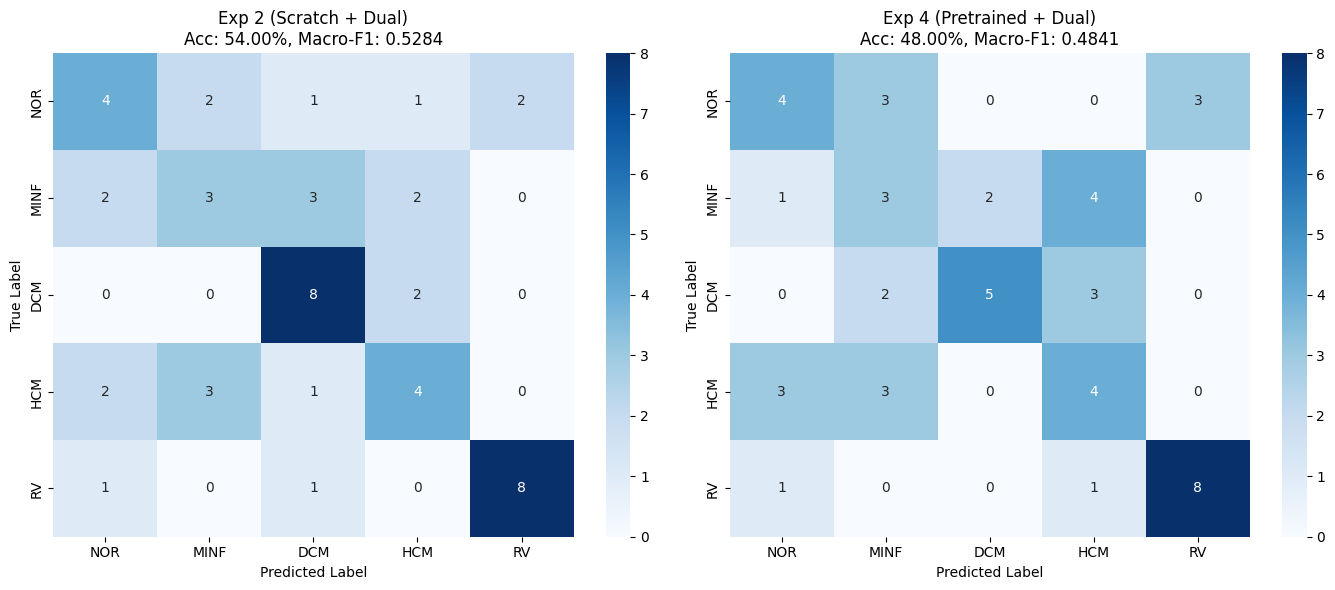

Comparative confusion matrices saved to: /content/drive/MyDrive/ACDC_VideoMamba_Transfer/test_confusion_matrices_exp2_vs_exp4.png


In [8]:
# ==============================================================================
# Cell 8: Independent Test Set Evaluation via 3-Fold Soft-Voting Ensemble
# Description:
# 1. Executes evaluation on 50 independent test patients (data augmentation disabled).
# 2. Benchmarks Exp 2 (Scratch) vs Exp 4 (Pretrained) using soft-voting probability averaging.
# 3. Reports Test Accuracy, Macro-F1, Classification Reports, and exports
#    high-resolution comparative confusion matrix heatmaps.
# ==============================================================================

import pandas as pd
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

TEST_DATASET_DIR = '/content/dataset/testing'
INV_DIAGNOSIS_MAP = {0: 'NOR', 1: 'MINF', 2: 'DCM', 3: 'HCM', 4: 'RV'}
TARGET_NAMES = ['NOR', 'MINF', 'DCM', 'HCM', 'RV']

class ACDCTestDataset(Dataset):
    """Independent test set loader supporting both labeled and blind evaluation modes."""
    def __init__(self, dataset_dir):
        self.patient_folders = sorted(glob.glob(os.path.join(dataset_dir, "patient*")))
        if len(self.patient_folders) == 0:
            self.patient_folders = sorted(glob.glob(os.path.join(dataset_dir, "**", "patient*"), recursive=True))

    def __len__(self):
        return len(self.patient_folders)

    def _pad_or_crop_3d(self, vol):
        z, h, w = vol.shape
        if z < TARGET_Z:
            vol = np.pad(vol, ((0, TARGET_Z - z), (0, 0), (0, 0)), mode='constant')
        elif z > TARGET_Z:
            st_z = (z - TARGET_Z) // 2
            vol = vol[st_z:st_z + TARGET_Z, :, :]

        if h < TARGET_H:
            p_h = TARGET_H - h
            vol = np.pad(vol, ((0, 0), (p_h // 2, p_h - p_h // 2), (0, 0)), mode='constant')
        elif h > TARGET_H:
            st_h = (h - TARGET_H) // 2
            vol = vol[:, st_h:st_h + TARGET_H, :]

        if w < TARGET_W:
            p_w = TARGET_W - w
            vol = np.pad(vol, ((0, 0), (0, 0), (p_w // 2, p_w - p_w // 2)), mode='constant')
        elif w > TARGET_W:
            st_w = (w - TARGET_W) // 2
            vol = vol[:, :, st_w:st_w + TARGET_W]
        return vol

    def __getitem__(self, idx):
        p_path = self.patient_folders[idx]
        p_id = os.path.basename(p_path)

        label = -1
        cfg_file = os.path.join(p_path, 'Info.cfg')
        if os.path.exists(cfg_file):
            with open(cfg_file, 'r', encoding='utf-8') as f:
                for line in f:
                    if line.startswith('Group:'):
                        g_str = line.split(':')[1].strip().upper()
                        if g_str in DIAGNOSIS_MAP:
                            label = DIAGNOSIS_MAP[g_str]
                        break

        cine_file = os.path.join(p_path, f"{p_id}_4d.nii.gz")
        data_4d = np.transpose(nib.load(cine_file).get_fdata(dtype=np.float32), (3, 2, 0, 1))

        indices = np.linspace(0, data_4d.shape[0] - 1, TARGET_T).astype(int)
        data_4d = data_4d[indices]

        processed = []
        for t in range(TARGET_T):
            frame = self._pad_or_crop_3d(data_4d[t])
            mean, std = np.mean(frame), np.std(frame) + 1e-8
            processed.append((frame - mean) / std)

        tensor_4d = torch.from_numpy(np.stack(processed, axis=0)).float().unsqueeze(0)
        return tensor_4d, torch.tensor(label, dtype=torch.long), p_id

class DualPoolingVideoMamba(nn.Module):
    """Inference network aligned with Exp 2 and Exp 4 checkpoint architectures."""
    def __init__(self, embed_dim=192, depth=6, num_classes=5):
        super().__init__()
        self.embed_dim = embed_dim
        self.spatial_encoder = nn.Sequential(
            nn.Conv3d(1, 32, kernel_size=3, stride=(1, 2, 2), padding=1),
            nn.BatchNorm3d(32),
            nn.SiLU(),
            nn.Conv3d(32, 64, kernel_size=3, stride=(1, 2, 2), padding=1),
            nn.BatchNorm3d(64),
            nn.SiLU(),
            nn.Conv3d(64, embed_dim, kernel_size=3, stride=(2, 2, 2), padding=1),
            nn.BatchNorm3d(embed_dim),
            nn.SiLU(),
            nn.AdaptiveAvgPool3d((1, 1, 1))
        )
        self.blocks = nn.ModuleList([VideoMambaBlock(embed_dim=embed_dim) for _ in range(depth)])
        self.norm = nn.LayerNorm(embed_dim)
        self.head = nn.Sequential(
            nn.Linear(embed_dim * 2, 64),
            nn.LayerNorm(64),
            nn.SiLU(),
            nn.Dropout(0.4),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        B, C, T, Z, H, W = x.shape
        x_flat = rearrange(x, 'b c t z h w -> (b t) c z h w')
        tokens = self.spatial_encoder(x_flat).flatten(1)
        seq = rearrange(tokens, '(b t) d -> b t d', b=B, t=T)
        for blk in self.blocks:
            seq = blk(seq)
        seq = self.norm(seq)
        t_mean = torch.mean(seq, dim=1)
        t_max, _ = torch.max(seq, dim=1)
        feat = torch.cat([t_mean, t_max], dim=-1)
        return self.head(feat)

def evaluate_experiment_ensemble(weight_patterns, exp_title, output_csv_name):
    print(f"\n{'='*25} Launching Test Evaluation: {exp_title} {'='*25}")

    model_paths = []
    for pat in weight_patterns:
        model_paths.extend(glob.glob(os.path.join(SAVE_DIR, pat)))
    model_paths = sorted(list(set(model_paths)))

    if len(model_paths) == 0:
        print(f"No checkpoint files found for {exp_title} under {SAVE_DIR}.")
        return None

    print(f"Loaded {len(model_paths)} fold checkpoints:")
    for mp in model_paths:
        print(f"  - {os.path.basename(mp)}")

    # Instantiate and restore model checkpoints
    model_list = []
    for mp in model_paths:
        m = DualPoolingVideoMamba(embed_dim=EMBED_DIM, depth=DEPTH, num_classes=NUM_CLASSES).to(DEVICE)
        state_dict = torch.load(mp, map_location=DEVICE)
        if 'model' in state_dict:
            state_dict = state_dict['model']
        m.load_state_dict(state_dict, strict=True)
        m.eval()
        model_list.append(m)

    test_dataset = ACDCTestDataset(TEST_DATASET_DIR)
    test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False, num_workers=2)

    patient_ids, true_labels, pred_labels, pred_probs = [], [], [], []

    # Soft-voting ensemble prediction
    with torch.no_grad():
        for data, label, p_id in test_loader:
            data = data.to(DEVICE)
            ensemble_prob = torch.zeros(1, NUM_CLASSES, device=DEVICE)
            with torch.amp.autocast('cuda', dtype=torch.bfloat16):
                for m in model_list:
                    logits = m(data)
                    ensemble_prob += F.softmax(logits, dim=1)

            ensemble_prob /= len(model_list)
            pred_idx = torch.argmax(ensemble_prob, dim=1).item()

            patient_ids.append(p_id[0])
            pred_labels.append(pred_idx)
            pred_probs.append(ensemble_prob.cpu().numpy()[0])
            true_labels.append(label.item())

    # Export inference results to CSV
    res_df = pd.DataFrame({
        'Patient_ID': patient_ids,
        'Predicted_Group': [INV_DIAGNOSIS_MAP[p] for p in pred_labels],
        'Confidence': [np.max(p) for p in pred_probs]
    })
    csv_path = os.path.join(SAVE_DIR, output_csv_name)
    res_df.to_csv(csv_path, index=False)
    print(f"Inference predictions exported to: {csv_path}")

    # Evaluate metrics if ground truth labels exist
    has_labels = all(l != -1 for l in true_labels)
    if has_labels:
        acc = accuracy_score(true_labels, pred_labels)
        f1 = f1_score(true_labels, pred_labels, average='macro')
        cm = confusion_matrix(true_labels, pred_labels)

        print(f"\n[{exp_title}] Test Evaluation Results:")
        print(f"Test Accuracy : {acc * 100:.2f}%")
        print(f"Test Macro-F1: {f1:.4f}")
        print("\nClassification Report:")
        print(classification_report(true_labels, pred_labels, target_names=TARGET_NAMES, digits=4))
        return {'cm': cm, 'acc': acc, 'f1': f1, 'title': exp_title}
    else:
        print("Notice: Ground-truth labels unavailable in Info.cfg. Metrics skipped.")
        return None

# 1. Evaluate Exp 2 (From Scratch + Dual Pooling)
res_exp2 = evaluate_experiment_ensemble(
    weight_patterns=["*exp2*best_fold*.pth"],
    exp_title="Exp 2 (Scratch + Dual)",
    output_csv_name="predictions_test_exp2.csv"
)

# 2. Evaluate Exp 4 (VideoMamba Pretrained + Dual Pooling)
res_exp4 = evaluate_experiment_ensemble(
    weight_patterns=["*exp4*best_fold*.pth", "videomamba_best_fold*.pth"],
    exp_title="Exp 4 (Pretrained + Dual)",
    output_csv_name="predictions_test_exp4.csv"
)

# 3. Render and save side-by-side confusion matrices
if res_exp2 and res_exp4:
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Confusion Matrix: Exp 2
    sns.heatmap(res_exp2['cm'], annot=True, fmt='d', cmap='Blues',
                xticklabels=TARGET_NAMES, yticklabels=TARGET_NAMES, ax=axes[0])
    axes[0].set_title(f"{res_exp2['title']}\nAcc: {res_exp2['acc']*100:.2f}%, Macro-F1: {res_exp2['f1']:.4f}", fontsize=12)
    axes[0].set_xlabel('Predicted Label')
    axes[0].set_ylabel('True Label')

    # Confusion Matrix: Exp 4
    sns.heatmap(res_exp4['cm'], annot=True, fmt='d', cmap='Blues',
                xticklabels=TARGET_NAMES, yticklabels=TARGET_NAMES, ax=axes[1])
    axes[1].set_title(f"{res_exp4['title']}\nAcc: {res_exp4['acc']*100:.2f}%, Macro-F1: {res_exp4['f1']:.4f}", fontsize=12)
    axes[1].set_xlabel('Predicted Label')
    axes[1].set_ylabel('True Label')

    plt.tight_layout()
    out_fig = os.path.join(SAVE_DIR, "test_confusion_matrices_exp2_vs_exp4.png")
    plt.savefig(out_fig, dpi=300)
    plt.show()
    print(f"Comparative confusion matrices saved to: {out_fig}")